
# 🌐 NLP

Ce notebook suit un pipeline complet de NLP, basé sur le plan retenu :

1. Text Acquisition  
2. Exploration et Analyse de Texte (EDA)   
3. Keywords extraction


---
## 1. Text Acquisition Chanson Formidable de Stromae

Nous allons collecter du texte à partir de différentes sources :

| Source | Outil utilisé | Exemple       | Caractéristique               |
| ------ | ------------- | ------------- | ----------------------------- |
| PDF    | pdfplumber    | Article arXiv | Texte scientifique, structuré |
| Audio  | Whisper       | Sermon 30 sec | Transcription orale           |

- Collecte de textes à partir de sites web, réseaux sociaux, documents, bases de données.  
- Notion de corpus : taille, diversité, domaine.


In [1]:
# Télécharger le fichier CSV directement depuis GitHub
!wget https://raw.githubusercontent.com/bidoscar/AFRICITIZEN-ACDS-Coding/main/Seance_9_NLP/Datasets/Paroles_de_formidable_Stromae.pdf

--2025-10-07 18:50:47--  https://raw.githubusercontent.com/bidoscar/AFRICITIZEN-ACDS-Coding/main/Seance_9_NLP/Datasets/Paroles_de_formidable_Stromae.pdf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 75976 (74K) [application/octet-stream]
Saving to: ‘Paroles_de_formidable_Stromae.pdf’

Paroles_de_formidab 100%[===================>]  74.20K  --.-KB/s    in 0.01s   

2025-10-07 18:50:47 (5.77 MB/s) - ‘Paroles_de_formidable_Stromae.pdf’ saved [75976/75976]



In [2]:
# Télécharger le fichier CSV directement depuis GitHub
!wget https://raw.githubusercontent.com/bidoscar/AFRICITIZEN-ACDS-Coding/main/Seance_9_NLP/Datasets/Stromae_-_Formidable_FeelMP3.com.mp3

--2025-10-07 18:50:52--  https://raw.githubusercontent.com/bidoscar/AFRICITIZEN-ACDS-Coding/main/Seance_9_NLP/Datasets/Stromae_-_Formidable_FeelMP3.com.mp3
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8590150 (8.2M) [audio/mpeg]
Saving to: ‘Stromae_-_Formidable_FeelMP3.com.mp3’

Stromae_-_Formidabl 100%[===================>]   8.19M  --.-KB/s    in 0.08s   

2025-10-07 18:50:52 (101 MB/s) - ‘Stromae_-_Formidable_FeelMP3.com.mp3’ saved [8590150/8590150]



### 📄 Exemple PDF (extraction de texte)

In [3]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 66.9 MB/s eta 0:00:00


In [9]:
import pdfplumber, os

pdf_path = "Paroles_de_formidable_Stromae.pdf"
text_pdf = ""

with pdfplumber.open(pdf_path) as pdf:

    for page in pdf.pages:
        text_pdf += page.extract_text()

In [10]:
text_pdf

'[Paroles de "Formidable"]\n[Refrain]\nFormidable, formidable\nTu étais formidable, j\'étais fort minable\nNous étions formidables\nFormidable\nTu étais formidable, j\'étais fort minable\nNous étions formidables\n[Couplet 1]\nOh bébé - oups ! - mademoiselle\nJ\'vais pas vous draguer, promis juré\nJ\'suis célibataire, depuis hier putain !\nJ\'peux pas faire d\'enfant et bon c\'est pas - Eh reviens !\nCinq minutes quoi ! J\'t\'ai pas insultée\nJ\'suis poli, courtois, et un peu fort bourré\nEt pour les mecs comme moi, vous avez autre chose à faire hein\nVous m\'auriez vu hier...\nJ\'étais...\n[Couplet 2]\nEh tu t\'es regardé, tu t\'crois beau parce que tu t\'es marié\nMais c\'est qu\'un anneau, mec, t\'emballe pas\nElle va t\'larguer comme elles le font chaque fois\nEt puis l\'autre fille, tu lui en as parlé ?\nSi tu veux je lui dis, comme ça c\'est réglé\nEt au p\'tit aussi, enfin si vous en avez\nAttends trois ans, sept ans, et là vous verrez\nSi c\'est...\n[Couplet 3]\nEt petite - oh p

### 🎙 Exemple Audio → Texte (Whisper)

In [6]:
!pip install openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 14.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=897ff2185c429b53d9e3ff3f325346f881f2ebbe78eece2dd61ce156d6ad63e0
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [7]:
import whisper
model = whisper.load_model("tiny")
audio_path = "Stromae_-_Formidable_FeelMP3.com.mp3"
result = model.transcribe(audio_path)
text_audio = result.get("text","")

100%|█████████████████████████████████████| 72.1M/72.1M [00:00<00:00, 99.1MiB/s]
/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


In [8]:
print(text_audio)

 Faut m'y d'able Faut m'y d'able Tu étais formidable, j'étais formidable Vous étions formidable Faut m'y d'able Tu étais formidable, j'étais formidable Nous étions formidable Faut m'y d'able Faut m'y d'able Faut se m'admoiser, j'vais pas vous draguer Promissurer, je suis célibataire Des pouillères, putain Je peux pas faire un enfant et bon, c'est pas à air Un via, c'est un minute quoi J'étais pas insulté Je suis poly, courtois et un peu forts bourrer Mes poulets, comme moi, ça veut, autre chose à faire Mourillèvue, j'étais formidable Faut m'y d'able Tu étais formidable, j'étais formidable Vous étions formidable Faut m'y d'able Tu étais formidable, j'étais formidable Nous étions formidable Faut m'y d'able Tu te crois beau, parce que tu t'es marié Mais c'est qu'un anomac T'en balba, elle va te larguer Comme elle le font chaque fois Et puis l'autre fille, tu n'es en apparlée Tu veux, je lui dis Comme ça c'est réglée Et obitie aussi, enfin si vous en avez Attends trois ans, c'est en est là

## 2. WORD TOKENNIZATION

In [25]:
import nltk

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    # Download the 'punkt' tokenizer models for all languages, including French.
    nltk.download('punkt')

try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    # Download the 'punkt_tab' tokenizer models.
    nltk.download('punkt_tab')


try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [26]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
import string

In [30]:
tokenized_text = word_tokenize(text_pdf)
print(tokenized_text)

['[', 'Paroles', 'de', '``', 'Formidable', "''", ']', '[', 'Refrain', ']', 'Formidable', ',', 'formidable', 'Tu', 'étais', 'formidable', ',', "j'étais", 'fort', 'minable', 'Nous', 'étions', 'formidables', 'Formidable', 'Tu', 'étais', 'formidable', ',', "j'étais", 'fort', 'minable', 'Nous', 'étions', 'formidables', '[', 'Couplet', '1', ']', 'Oh', 'bébé', '-', 'oups', '!', '-', 'mademoiselle', "J'vais", 'pas', 'vous', 'draguer', ',', 'promis', 'juré', "J'suis", 'célibataire', ',', 'depuis', 'hier', 'putain', '!', "J'peux", 'pas', 'faire', "d'enfant", 'et', 'bon', "c'est", 'pas', '-', 'Eh', 'reviens', '!', 'Cinq', 'minutes', 'quoi', '!', "J't'ai", 'pas', 'insultée', "J'suis", 'poli', ',', 'courtois', ',', 'et', 'un', 'peu', 'fort', 'bourré', 'Et', 'pour', 'les', 'mecs', 'comme', 'moi', ',', 'vous', 'avez', 'autre', 'chose', 'à', 'faire', 'hein', 'Vous', "m'auriez", 'vu', 'hier', '...', "J'étais", '...', '[', 'Couplet', '2', ']', 'Eh', 'tu', "t'es", 'regardé', ',', 'tu', "t'crois", 'beau',

In [28]:
len(tokenized_text)

282

## **Normalisation**

In [29]:
# garder uniquement les tokens alphabetiques
tokenized_text_alpha = [word for word in tokenized_text if word.isalpha()]

print(tokenized_text_alpha)

['Paroles', 'de', 'Formidable', 'Refrain', 'Formidable', 'formidable', 'Tu', 'étais', 'formidable', 'fort', 'minable', 'Nous', 'étions', 'formidables', 'Formidable', 'Tu', 'étais', 'formidable', 'fort', 'minable', 'Nous', 'étions', 'formidables', 'Couplet', 'Oh', 'bébé', 'oups', 'mademoiselle', 'pas', 'vous', 'draguer', 'promis', 'juré', 'célibataire', 'depuis', 'hier', 'putain', 'pas', 'faire', 'et', 'bon', 'pas', 'Eh', 'reviens', 'Cinq', 'minutes', 'quoi', 'pas', 'insultée', 'poli', 'courtois', 'et', 'un', 'peu', 'fort', 'bourré', 'Et', 'pour', 'les', 'mecs', 'comme', 'moi', 'vous', 'avez', 'autre', 'chose', 'à', 'faire', 'hein', 'Vous', 'vu', 'hier', 'Couplet', 'Eh', 'tu', 'regardé', 'tu', 'beau', 'parce', 'que', 'tu', 'marié', 'Mais', 'anneau', 'mec', 'pas', 'Elle', 'va', 'comme', 'elles', 'le', 'font', 'chaque', 'fois', 'Et', 'puis', 'fille', 'tu', 'lui', 'en', 'as', 'parlé', 'Si', 'tu', 'veux', 'je', 'lui', 'dis', 'comme', 'ça', 'réglé', 'Et', 'au', 'aussi', 'enfin', 'si', 'vous'

In [35]:
len(tokenized_text_alpha)

194

In [31]:
tokenized_text_alpha_lower = [word.lower() for word in tokenized_text_alpha]
print(tokenized_text_alpha_lower)

['paroles', 'de', 'formidable', 'refrain', 'formidable', 'formidable', 'tu', 'étais', 'formidable', 'fort', 'minable', 'nous', 'étions', 'formidables', 'formidable', 'tu', 'étais', 'formidable', 'fort', 'minable', 'nous', 'étions', 'formidables', 'couplet', 'oh', 'bébé', 'oups', 'mademoiselle', 'pas', 'vous', 'draguer', 'promis', 'juré', 'célibataire', 'depuis', 'hier', 'putain', 'pas', 'faire', 'et', 'bon', 'pas', 'eh', 'reviens', 'cinq', 'minutes', 'quoi', 'pas', 'insultée', 'poli', 'courtois', 'et', 'un', 'peu', 'fort', 'bourré', 'et', 'pour', 'les', 'mecs', 'comme', 'moi', 'vous', 'avez', 'autre', 'chose', 'à', 'faire', 'hein', 'vous', 'vu', 'hier', 'couplet', 'eh', 'tu', 'regardé', 'tu', 'beau', 'parce', 'que', 'tu', 'marié', 'mais', 'anneau', 'mec', 'pas', 'elle', 'va', 'comme', 'elles', 'le', 'font', 'chaque', 'fois', 'et', 'puis', 'fille', 'tu', 'lui', 'en', 'as', 'parlé', 'si', 'tu', 'veux', 'je', 'lui', 'dis', 'comme', 'ça', 'réglé', 'et', 'au', 'aussi', 'enfin', 'si', 'vous'

## **Stop words**

In [32]:
stop_words = set(stopwords.words('french'))
stop_words

{'ai',
 'aie',
 'aient',
 'aies',
 'ait',
 'as',
 'au',
 'aura',
 'aurai',
 'auraient',
 'aurais',
 'aurait',
 'auras',
 'aurez',
 'auriez',
 'aurions',
 'aurons',
 'auront',
 'aux',
 'avaient',
 'avais',
 'avait',
 'avec',
 'avez',
 'aviez',
 'avions',
 'avons',
 'ayant',
 'ayante',
 'ayantes',
 'ayants',
 'ayez',
 'ayons',
 'c',
 'ce',
 'ces',
 'd',
 'dans',
 'de',
 'des',
 'du',
 'elle',
 'en',
 'es',
 'est',
 'et',
 'eu',
 'eue',
 'eues',
 'eurent',
 'eus',
 'eusse',
 'eussent',
 'eusses',
 'eussiez',
 'eussions',
 'eut',
 'eux',
 'eûmes',
 'eût',
 'eûtes',
 'furent',
 'fus',
 'fusse',
 'fussent',
 'fusses',
 'fussiez',
 'fussions',
 'fut',
 'fûmes',
 'fût',
 'fûtes',
 'il',
 'ils',
 'j',
 'je',
 'l',
 'la',
 'le',
 'les',
 'leur',
 'lui',
 'm',
 'ma',
 'mais',
 'me',
 'mes',
 'moi',
 'mon',
 'même',
 'n',
 'ne',
 'nos',
 'notre',
 'nous',
 'on',
 'ont',
 'ou',
 'par',
 'pas',
 'pour',
 'qu',
 'que',
 'qui',
 's',
 'sa',
 'se',
 'sera',
 'serai',
 'seraient',
 'serais',
 'serait',


In [34]:
tokenized_text_alpha_lower_no_stopwords = [word for word in tokenized_text_alpha_lower if word not in stop_words]
print(len(tokenized_text_alpha_lower_no_stopwords))
print(tokenized_text_alpha_lower_no_stopwords)

124
['paroles', 'formidable', 'refrain', 'formidable', 'formidable', 'formidable', 'fort', 'minable', 'formidables', 'formidable', 'formidable', 'fort', 'minable', 'formidables', 'couplet', 'oh', 'bébé', 'oups', 'mademoiselle', 'draguer', 'promis', 'juré', 'célibataire', 'depuis', 'hier', 'putain', 'faire', 'bon', 'eh', 'reviens', 'cinq', 'minutes', 'quoi', 'insultée', 'poli', 'courtois', 'peu', 'fort', 'bourré', 'mecs', 'comme', 'autre', 'chose', 'faire', 'hein', 'vu', 'hier', 'couplet', 'eh', 'regardé', 'beau', 'parce', 'marié', 'anneau', 'mec', 'va', 'comme', 'elles', 'font', 'chaque', 'fois', 'puis', 'fille', 'parlé', 'si', 'veux', 'dis', 'comme', 'ça', 'réglé', 'aussi', 'enfin', 'si', 'attends', 'trois', 'ans', 'sept', 'ans', 'là', 'verrez', 'si', 'couplet', 'petite', 'oh', 'pardon', 'petit', 'sais', 'vie', 'a', 'ni', 'méchant', 'ni', 'gentil', 'si', 'maman', 'chiante', 'a', 'peur', 'mamie', 'si', 'papa', 'trompe', 'maman', 'parce', 'maman', 'vieillit', 'tiens', 'pourquoi', 'tout'

In [36]:
my_stop_words = ["paroles", "couplet", "refrain"]
tokenized_text_alpha_lower_no_stopwords_perso = [word for word in tokenized_text_alpha_lower_no_stopwords if word not in my_stop_words]
print(len(tokenized_text_alpha_lower_no_stopwords_perso))
print(tokenized_text_alpha_lower_no_stopwords_perso)

119
['formidable', 'formidable', 'formidable', 'formidable', 'fort', 'minable', 'formidables', 'formidable', 'formidable', 'fort', 'minable', 'formidables', 'oh', 'bébé', 'oups', 'mademoiselle', 'draguer', 'promis', 'juré', 'célibataire', 'depuis', 'hier', 'putain', 'faire', 'bon', 'eh', 'reviens', 'cinq', 'minutes', 'quoi', 'insultée', 'poli', 'courtois', 'peu', 'fort', 'bourré', 'mecs', 'comme', 'autre', 'chose', 'faire', 'hein', 'vu', 'hier', 'eh', 'regardé', 'beau', 'parce', 'marié', 'anneau', 'mec', 'va', 'comme', 'elles', 'font', 'chaque', 'fois', 'puis', 'fille', 'parlé', 'si', 'veux', 'dis', 'comme', 'ça', 'réglé', 'aussi', 'enfin', 'si', 'attends', 'trois', 'ans', 'sept', 'ans', 'là', 'verrez', 'si', 'petite', 'oh', 'pardon', 'petit', 'sais', 'vie', 'a', 'ni', 'méchant', 'ni', 'gentil', 'si', 'maman', 'chiante', 'a', 'peur', 'mamie', 'si', 'papa', 'trompe', 'maman', 'parce', 'maman', 'vieillit', 'tiens', 'pourquoi', 'tout', 'rouge', 'ben', 'reviens', 'gamin', 'tous', 'regarder

## **Lemmatisation and stemmasation**

## 🔹 **Lemmatization**

* **But** : ramener un mot à sa **forme canonique** (lemmatisation) en respectant la grammaire et le dictionnaire.
* Exemple :

  * *"mangeons"* → **"manger"**
  * *"meilleures"* → **"meilleur"**
  * *"couraient"* → **"courir"**
* C’est **linguistiquement correct** → on garde le sens du mot.
* Outils : WordNet (anglais), spaCy/Stanza (français).

---

## 🔹 **Stemming**

* **But** : couper le mot pour obtenir une **racine** (radical) via des règles simples (pas de grammaire).
* Exemple :

  * *"mangeons"* → **"mange"**
  * *"meilleures"* → **"meilleur"** (ok ici mais pas toujours)
  * *"couraient"* → **"cour"** (perd le sens exact)
* C’est **plus rapide**, mais **plus brutal** → on risque de perdre de la précision.
* Outils : PorterStemmer, SnowballStemmer.

---

## ⚖️ Résumé rapide

| Méthode        | Exemple mot | Résultat   | Avantage                         | Inconvénient                              |
| -------------- | ----------- | ---------- | -------------------------------- | ----------------------------------------- |
| **Lemmatizer** | *couraient* | **courir** | Respecte le sens et la grammaire | Plus lent                                 |
| **Stemmer**    | *couraient* | **cour**   | Rapide, simple                   | Perte d’info, pas toujours un mot correct |

In [40]:
lemmatizer = WordNetLemmatizer()
list_lemmas = [lemmatizer.lemmatize(w) for w in tokenized_text_alpha_lower_no_stopwords_perso]

In [46]:
list_lemmas[26], list_lemmas[30], list_lemmas[6]

('reviens', 'insultée', 'formidables')

In [47]:
tokenized_text_alpha_lower_no_stopwords_perso[26], tokenized_text_alpha_lower_no_stopwords_perso[30], tokenized_text_alpha_lower_no_stopwords_perso[6]

('reviens', 'insultée', 'formidables')

In [48]:
stemmer = PorterStemmer()
list_stems = [stemmer.stem(w) for w in tokenized_text_alpha_lower_no_stopwords_perso]

In [49]:
list_stems[26], list_stems[30], list_stems[6]

('revien', 'insulté', 'formid')


---
## 2. Exploration et Analyse de Texte (EDA)

- Statistiques de base : nombre de documents, nombre moyen de mots par document.  
- Vocabulaire unique : taille du lexique.  
- Fréquences des mots : top 10, distribution des longueurs de mots.  
- Visualisations : nuages de mots (wordcloud), histogrammes.  
- Importance de "voir" les données avant de les transformer.


In [51]:
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

In [59]:
def eda_report (text, top_words):
  vocab = set(text)
  counts = Counter(text)
  print(f"Taille du corpus : {len(text)} tokens")
  print(f"Taille du vocabulaire : {len(vocab)} tokens")
  print(f"Nombre moyen de tokens par document : {round(len(text)/len(vocab),2)}")
  print("Top 10 des tokens les plus fréquents :")
  for word in counts.most_common(top_words):
    print("------------")
    print(f"{word[0]} : {word[1]}")

In [61]:
eda_report(tokenized_text_alpha_lower_no_stopwords_perso, 30)

Taille du corpus : 119 tokens
Taille du vocabulaire : 90 tokens
Nombre moyen de tokens par document : 1.32
Top 10 des tokens les plus fréquents :
------------
formidable : 6
------------
si : 5
------------
comme : 4
------------
fort : 3
------------
maman : 3
------------
minable : 2
------------
formidables : 2
------------
oh : 2
------------
bébé : 2
------------
hier : 2
------------
faire : 2
------------
eh : 2
------------
reviens : 2
------------
parce : 2
------------
ans : 2
------------
a : 2
------------
ni : 2
------------
singe : 2
------------
oups : 1
------------
mademoiselle : 1
------------
draguer : 1
------------
promis : 1
------------
juré : 1
------------
célibataire : 1
------------
depuis : 1
------------
putain : 1
------------
bon : 1
------------
cinq : 1
------------
minutes : 1
------------
quoi : 1


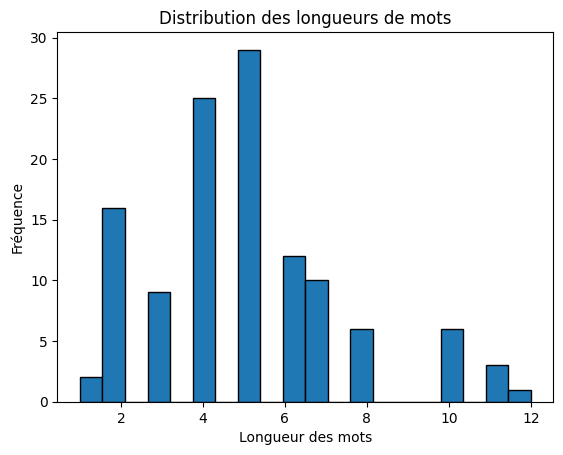

In [62]:
# Histogramme des longueurs de mots dans le corpus
word_lengths = [len(word) for word in tokenized_text_alpha_lower_no_stopwords_perso]
plt.hist(word_lengths, bins=20, edgecolor='black')
plt.xlabel('Longueur des mots')
plt.ylabel('Fréquence')
plt.title('Distribution des longueurs de mots')
plt.show()

In [63]:
my_vocab = set(tokenized_text_alpha_lower_no_stopwords_perso)

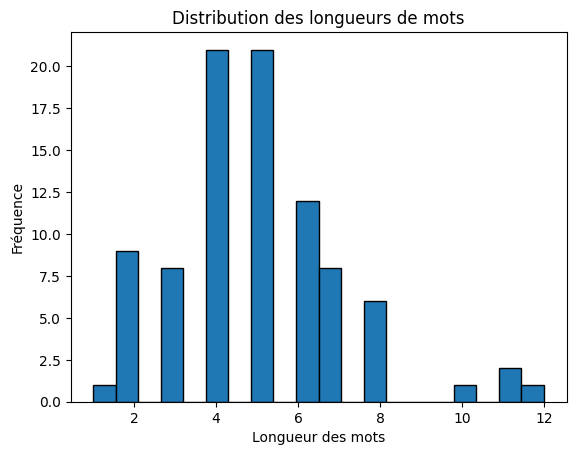

In [64]:
# Histogramme des longueurs de mots dans le vocabulaire
word_lengths = [len(word) for word in my_vocab]
plt.hist(word_lengths, bins=20, edgecolor='black')
plt.xlabel('Longueur des mots')
plt.ylabel('Fréquence')
plt.title('Distribution des longueurs de mots')
plt.show()

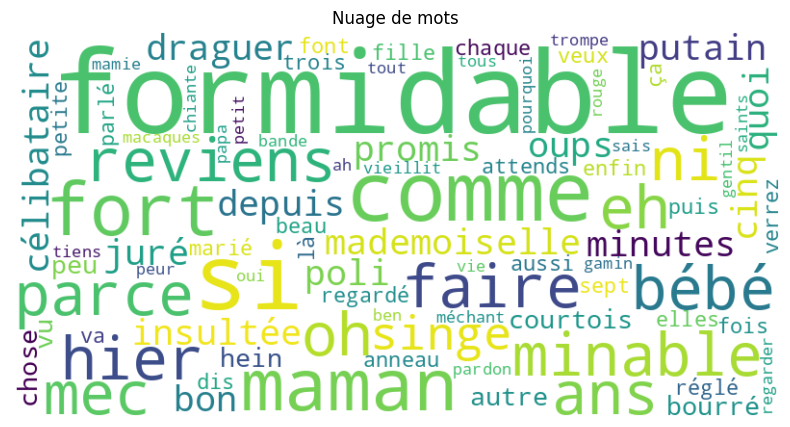

In [65]:
# Nuage des mots
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(tokenized_text_alpha_lower_no_stopwords_perso))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuage de mots')
plt.show()